# AKT 1 — oś decydującego momentu (z kontrolą konfoundów)

## Cel i logika

Szukamy kierunku w przestrzeni CLIP, który rozdziela **chosen** (wybrane przez Strykera) od **rejected** (killed) — kandydata na oś decydującego momentu. Ale wiemy, że dziurka (hole punch) i ostrość też rozdzielają te klasy. Dlatego struktura to **porównanie przed/po neutralizacji**:

1. **Oś surowa** — decisive_direction + d' + linear probe na oryginalnych embeddingach (linia bazowa, skażona konfoundami)
2. **Konfoundy** — dziurka (detektor CV) i ostrość (twarda metoda: wariancja Laplasjanu, nie prompt)
3. **Neutralizacja** — projekcja przez confound_pipeline (podprzestrzeń)
4. **Oś czysta** — te same miary po neutralizacji
5. **WERDYKT** — czy separacja przetrwała?
   - przetrwała (d' spadło, ale istotne) → sygnał prawdziwy, jest coś poza konfoundami
   - zniknęła (d'→0) → "oś momentu" była artefaktem konfoundów
6. **Analiza per sim_level** — sygnał powinien być silniejszy w parach *wyrazny* niż *mikroruch* (test spójności)

## Wejście (Drive)
- `fsa_pairs_filtered.csv` (14266 par, kolumna sim_level)
- `clip_embeddings.npz` (gotowe embeddingi)
- `fsa_images/` (do detekcji dziurki i Laplasjanu)
- `confound_pipeline.py` (upload do Colab)


## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q open_clip_torch scikit-learn 2>/dev/null


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00


In [2]:
import json, re, os
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
np.set_printoptions(precision=4, suppress=True)

DRIVE = Path('/content/drive/MyDrive/fsa_data')
PAIRS = DRIVE / 'fsa_pairs_filtered.csv'
EMB_CACHE = DRIVE / 'clip_embeddings.npz'
IMAGES_DIR = DRIVE / 'fsa_images'
SHARP_CACHE = DRIVE / 'sharpness_cache.npz'      # cache Laplasjanu
HOLE_CACHE = DRIVE / 'hole_detection_cache.csv'  # cache detekcji dziurki

# Wgraj confound_pipeline.py jeśli brak
if not os.path.exists('confound_pipeline.py'):
    from google.colab import files
    print('Wgraj confound_pipeline.py:')
    files.upload()
from confound_pipeline import ConfoundController
print('✅ Pipeline konfoundów załadowany')


Wgraj confound_pipeline.py:


Saving confound_pipeline.py to confound_pipeline.py
✅ Pipeline konfoundów załadowany


## 1. Wczytaj pary i embeddingi (z cache — bez liczenia)

In [3]:
pairs = pd.read_csv(PAIRS, dtype={'similarity': float}, keep_default_na=False)
print(f'Pary: {len(pairs)}')
print(pairs['sim_level'].value_counts().to_string())

with np.load(EMB_CACHE, allow_pickle=True) as data:
    all_files = list(data['files'])
    all_emb = data['emb']            # dekompresja RAZ
file_to_idx = {f: i for i, f in enumerate(all_files)}
print(f'Embeddingi: {all_emb.shape}')

# Zbuduj macierze: E_chosen, E_rejected (wiersz = para)
ci = pairs['chosen_file'].map(lambda f: file_to_idx.get(f, -1)).values
ri = pairs['rejected_file'].map(lambda f: file_to_idx.get(f, -1)).values
ok = (ci >= 0) & (ri >= 0)
pairs = pairs[ok].reset_index(drop=True)
ci, ri = ci[ok], ri[ok]
E_c = all_emb[ci].astype(np.float64)   # chosen
E_r = all_emb[ri].astype(np.float64)   # rejected
print(f'Macierze par: chosen {E_c.shape}, rejected {E_r.shape}')


Pary: 14266
sim_level
bliski       6567
wyrazny      5585
mikroruch    2114
Embeddingi: (27891, 512)
Macierze par: chosen (14266, 512), rejected (14266, 512)


## 2. Train/test split — po parach

Dzielimy PARY (nie obrazy) na train (znajdź oś) i test (zmierz uczciwie). Bez tego d' byłoby zawyżone (oś dopasowana do tych samych danych, na których mierzymy).


In [4]:
rng = np.random.RandomState(42)
n = len(pairs)
perm = rng.permutation(n)
n_train = int(0.7 * n)
tr_idx, te_idx = perm[:n_train], perm[n_train:]
print(f'Train: {len(tr_idx)} par, Test: {len(te_idx)} par')

def dprime_paired(proj_c, proj_r):
    """d' dla rzutów chosen vs rejected."""
    a, b = proj_c, proj_r
    return abs(a.mean() - b.mean()) / (np.sqrt(0.5*(a.var()+b.var())) + 1e-12)


Train: 9986 par, Test: 4280 par


## 3. OŚ SUROWA — decisive_direction + d' + linear probe (linia bazowa)

In [5]:
from sklearn.linear_model import LogisticRegression

def find_axis_and_measure(Ec, Er, tr, te, label=''):
    """Znajduje oś na train, mierzy na test. Zwraca dict z wynikami."""
    # Metoda 1: kierunek różnicy średnich (na train)
    v = Ec[tr].mean(0) - Er[tr].mean(0)
    v = v / (np.linalg.norm(v) + 1e-12)
    d_test = dprime_paired(Ec[te] @ v, Er[te] @ v)

    # Metoda 2: linear probe (regresja logistyczna na train, acc na test)
    X_tr = np.vstack([Ec[tr], Er[tr]])
    y_tr = np.array([1]*len(tr) + [0]*len(tr))
    X_te = np.vstack([Ec[te], Er[te]])
    y_te = np.array([1]*len(te) + [0]*len(te))
    probe = LogisticRegression(max_iter=2000, C=1.0)
    probe.fit(X_tr, y_tr)
    acc = probe.score(X_te, y_te)
    w = probe.coef_[0] / (np.linalg.norm(probe.coef_[0]) + 1e-12)

    # Baseline permutacyjny — d' przy losowych etykietach (szum)
    rng2 = np.random.RandomState(0)
    d_perm = []
    for _ in range(20):
        sw = rng2.rand(len(tr)) < 0.5   # losowo zamień chosen<->rejected w train
        Ec_p = np.where(sw[:,None], Er[tr], Ec[tr])
        Er_p = np.where(sw[:,None], Ec[tr], Er[tr])
        vp = Ec_p.mean(0) - Er_p.mean(0)
        vp = vp / (np.linalg.norm(vp) + 1e-12)
        d_perm.append(dprime_paired(Ec[te] @ vp, Er[te] @ vp))
    d_noise = float(np.mean(d_perm))

    print(f'[{label}]')
    print(f'  d\' (mean-diff, test):     {d_test:.3f}   (szum/permutacja: {d_noise:.3f})')
    print(f'  linear probe acc (test):  {acc:.3f}   (szum: 0.500)')
    print(f'  cos(mean-diff, probe):    {float(np.dot(v, w)):.3f}   (zgodność metod)')
    return {'v': v, 'w': w, 'dprime': d_test, 'acc': acc, 'd_noise': d_noise}

raw = find_axis_and_measure(E_c, E_r, tr_idx, te_idx, 'OŚ SUROWA (przed neutralizacją)')


[OŚ SUROWA (przed neutralizacją)]
  d' (mean-diff, test):     0.240   (szum/permutacja: 0.028)
  linear probe acc (test):  0.581   (szum: 0.500)
  cos(mean-diff, probe):    0.607   (zgodność metod)


## 4. KONFOUND 1 — ostrość, twarda metoda (wariancja Laplasjanu)

Prompt CLIP pokazał d'=1.11 dla ostrości, ale to miękka metoda (modality gap). Tu potwierdzamy TWARDO: wariancja Laplasjanu = klasyczna miara ostrości obrazu. Z cache — liczy raz.


In [6]:
def laplacian_sharpness(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None: return np.nan
    # Przytnij ramkę filmu (12%) — mierz ostrość TREŚCI, nie ramki
    h, w = img.shape
    my, mx = int(0.12*h), int(0.12*w)
    crop = img[my:h-my, mx:w-mx]
    return float(cv2.Laplacian(crop, cv2.CV_64F).var())

# Cache: policz raz dla wszystkich unikalnych plików w parach
needed = pd.unique(pairs[['chosen_file','rejected_file']].values.ravel())
sharp = {}
if SHARP_CACHE.exists():
    with np.load(SHARP_CACHE, allow_pickle=True) as d:
        sharp = dict(zip(list(d['files']), d['vals']))
    print(f'Cache ostrości: {len(sharp)}')
todo = [f for f in needed if f not in sharp]
print(f'Do policzenia: {len(todo)}')
if todo:
    from tqdm.auto import tqdm
    for f in tqdm(todo, desc='Laplacian'):
        sharp[f] = laplacian_sharpness(IMAGES_DIR / f)
    np.savez_compressed(SHARP_CACHE, files=np.array(list(sharp.keys())), vals=np.array(list(sharp.values())))
    print('Cache zapisany')

sc = pairs['chosen_file'].map(sharp).values
sr = pairs['rejected_file'].map(sharp).values
print(f'\n=== TWARDY TEST OSTROŚCI ===')
print(f'Mediana ostrości chosen:   {np.nanmedian(sc):.1f}')
print(f'Mediana ostrości rejected: {np.nanmedian(sr):.1f}')
frac = np.nanmean(sc > sr)
print(f'Frakcja par gdzie chosen ostrzejsze: {frac:.2%}')
print('→ jeśli wyraźnie >50%, ostrość POTWIERDZONA jako konfound (zgodnie z promptem CLIP)')


Do policzenia: 21591


Laplacian:   0%|          | 0/21591 [00:00<?, ?it/s]

Cache zapisany

=== TWARDY TEST OSTROŚCI ===
Mediana ostrości chosen:   1672.4
Mediana ostrości rejected: 1504.0
Frakcja par gdzie chosen ostrzejsze: 57.28%
→ jeśli wyraźnie >50%, ostrość POTWIERDZONA jako konfound (zgodnie z promptem CLIP)


## 5. KONFOUND 2 — dziurka (detektor CV na obrazach rejected)

Detekcja z cache. Dla wykrytych: para orig/inpainted → kierunek dziurki w CLIP (from_detector).


In [7]:
def detect_hole(img_bgr):
    h, w = img_bgr.shape[:2]
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, dark = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY_INV)
    my, mx = int(0.12*h), int(0.12*w)
    center = np.zeros_like(dark); center[my:h-my, mx:w-mx] = 1
    dark = dark * center
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    dark = cv2.morphologyEx(dark, cv2.MORPH_CLOSE, k)
    contours, _ = cv2.findContours(dark, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    best = None
    for c in contours:
        area = cv2.contourArea(c)
        if area < 80: continue
        perim = cv2.arcLength(c, True)
        if perim == 0: continue
        circ = 4*np.pi*area/(perim*perim)
        (cx,cy), r = cv2.minEnclosingCircle(c)
        fill = area/(np.pi*r*r+1e-6)
        if circ>0.6 and fill>0.55 and 6<r<0.25*min(h,w):
            s = circ*fill
            if best is None or s>best['score']:
                best = dict(cx=float(cx),cy=float(cy),radius=float(r),score=float(s))
    return best

# Cache detekcji na plikach rejected
rej_files = pairs['rejected_file'].unique()
if HOLE_CACHE.exists():
    hole_df = pd.read_csv(HOLE_CACHE)
    done = set(hole_df['file'])
else:
    hole_df = pd.DataFrame(columns=['file','has_hole','cx','cy','radius'])
    done = set()
todo = [f for f in rej_files if f not in done]
print(f'Detekcja dziurki: cache {len(done)}, do zrobienia {len(todo)}')
if todo:
    from tqdm.auto import tqdm
    rows = []
    for f in tqdm(todo, desc='detect hole'):
        img = cv2.imread(str(IMAGES_DIR / f))
        h = detect_hole(img) if img is not None else None
        rows.append({'file': f, 'has_hole': h is not None,
                     'cx': h['cx'] if h else np.nan, 'cy': h['cy'] if h else np.nan,
                     'radius': h['radius'] if h else np.nan})
        if len(rows) % 500 == 0:
            hole_df = pd.concat([hole_df, pd.DataFrame(rows)], ignore_index=True)
            hole_df.to_csv(HOLE_CACHE, index=False); rows = []
    hole_df = pd.concat([hole_df, pd.DataFrame(rows)], ignore_index=True)
    hole_df.to_csv(HOLE_CACHE, index=False)

n_hole = hole_df['has_hole'].sum()
print(f'\n=== DZIURKA W REJECTED ===')
print(f'Rejected z dziurką: {n_hole}/{len(hole_df)} ({n_hole*100//max(len(hole_df),1)}%)')


Detekcja dziurki: cache 0, do zrobienia 14266


detect hole:   0%|          | 0/14266 [00:00<?, ?it/s]

/tmp/ipykernel_1194/609328779.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  hole_df = pd.concat([hole_df, pd.DataFrame(rows)], ignore_index=True)



=== DZIURKA W REJECTED ===
Rejected z dziurką: 1098/14266 (7%)


## 6. Zbuduj kierunki konfoundów (CLIP) i zneutralizuj

In [8]:
import torch, open_clip
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model = model.to(device).eval()

@torch.no_grad()
def clip_embed_bgr(img_bgr):
    pil = Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    x = preprocess(pil).unsqueeze(0).to(device)
    e = model.encode_image(x)
    e = e / e.norm(dim=-1, keepdim=True)
    return e[0].cpu().numpy().astype(np.float64)

ctrl = ConfoundController(image_embedder=clip_embed_bgr)

# --- Konfound HOLE: próbka wykrytych dziurek -> pary orig/inpaint ---
N_HOLE_SAMPLE = 150
hole_files = hole_df[hole_df['has_hole']]['file'].tolist()
sample_files = hole_files[:N_HOLE_SAMPLE]
def repair(img, det):
    mask = np.zeros(img.shape[:2], np.uint8)
    cv2.circle(mask, (int(det['cx']), int(det['cy'])), int(det['radius'])+4, 255, -1)
    return cv2.inpaint(img, mask, 5, cv2.INPAINT_TELEA)
imgs_hole = [cv2.imread(str(IMAGES_DIR / f)) for f in sample_files]
imgs_hole = [im for im in imgs_hole if im is not None]
print(f'Liczę kierunek dziurki na {len(imgs_hole)} obrazach (orig+inpaint x CLIP)...')
cd_hole = ctrl.from_detector('hole_punch', imgs_hole, detect_hole, repair)
print(f'  {cd_hole}')

# --- Konfound SHARPNESS: twarde etykiety z Laplasjanu -> from_labels ---
all_sharp_vals = np.array([sharp.get(f, np.nan) for f in all_files])
valid_s = ~np.isnan(all_sharp_vals)
q_low, q_high = np.nanpercentile(all_sharp_vals, [25, 75])
blurry_emb = all_emb[valid_s & (all_sharp_vals <= q_low)]
sharp_emb = all_emb[valid_s & (all_sharp_vals >= q_high)]
cd_sharp = ctrl.from_labels('sharpness', sharp_emb.astype(np.float64), blurry_emb.astype(np.float64))
print(f'  {cd_sharp}  (ostre_q75={len(sharp_emb)}, rozmyte_q25={len(blurry_emb)})')

# --- Neutralizacja (podprzestrzeń) ---
E_c_clean = ctrl.neutralize(E_c)
E_r_clean = ctrl.neutralize(E_r)
print(f'\n✅ Zneutralizowano {len(ctrl.directions)} konfoundów (podprzestrzeń)')
ver = ctrl.verify(np.vstack([E_c, E_r]))
print(f'  maks. rzut po neutralizacji: {ver["max_residual"]:.2e} (cel ~0)')


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Liczę kierunek dziurki na 150 obrazach (orig+inpaint x CLIP)...
  ConfoundDirection('hole_punch', method='detector', dim=512)
  ConfoundDirection('sharpness', method='labels', dim=512)  (ostre_q75=5398, rozmyte_q25=5398)

✅ Zneutralizowano 2 konfoundów (podprzestrzeń)
  maks. rzut po neutralizacji: 4.79e-16 (cel ~0)


## 7. OŚ CZYSTA — te same miary po neutralizacji + WERDYKT

In [9]:
clean = find_axis_and_measure(E_c_clean, E_r_clean, tr_idx, te_idx, 'OŚ CZYSTA (po neutralizacji)')

print('\n' + '='*64)
print('WERDYKT')
print('='*64)
print(f"d' surowe:  {raw['dprime']:.3f}   (szum: {raw['d_noise']:.3f})")
print(f"d' czyste:  {clean['dprime']:.3f}   (szum: {clean['d_noise']:.3f})")
print(f"probe acc surowa: {raw['acc']:.3f}  → czysta: {clean['acc']:.3f}")
drop = (raw['dprime'] - clean['dprime']) / max(raw['dprime'], 1e-9) * 100
print(f"\nSpadek d' po neutralizacji: {drop:.0f}%")
if clean['dprime'] > 3*clean['d_noise'] and clean['acc'] > 0.55:
    print('\n→ SYGNAŁ PRZETRWAŁ neutralizację konfoundów.')
    print('  Istnieje kierunek rozdzielający chosen/rejected NIEZALEŻNY od dziurki i ostrości.')
    print('  Kandydat na oś decydującego momentu → Akt 2 (interpretacja).')
else:
    print('\n→ Sygnał NIE przetrwał — separacja była głównie artefaktem konfoundów.')
    print('  Ważny wynik negatywny. Sprawdź poziomy sim_level poniżej i rozważ dalsze konfoundy.')


[OŚ CZYSTA (po neutralizacji)]
  d' (mean-diff, test):     0.195   (szum/permutacja: 0.028)
  linear probe acc (test):  0.564   (szum: 0.500)
  cos(mean-diff, probe):    0.518   (zgodność metod)

WERDYKT
d' surowe:  0.240   (szum: 0.028)
d' czyste:  0.195   (szum: 0.028)
probe acc surowa: 0.581  → czysta: 0.564

Spadek d' po neutralizacji: 19%

→ SYGNAŁ PRZETRWAŁ neutralizację konfoundów.
  Istnieje kierunek rozdzielający chosen/rejected NIEZALEŻNY od dziurki i ostrości.
  Kandydat na oś decydującego momentu → Akt 2 (interpretacja).


## 8. Analiza per sim_level — gdzie mieszka sygnał (test spójności)

Sygnał per poziom similarity (oś czysta liczona na train całości):

  wyrazny   : d'=0.291  (n=1643 par testowych)
  bliski    : d'=0.168  (n=2001 par testowych)
  mikroruch : d'=0.040  (n=636 par testowych)

Interpretacja:
  d' rosnące od mikroruch→wyrazny = oś łapie MOMENT (różnicę realnych ujęć)
  d' płaskie/odwrotne = oś łapie coś innego (kolejny konfound? sprawdzić w Akcie 2)


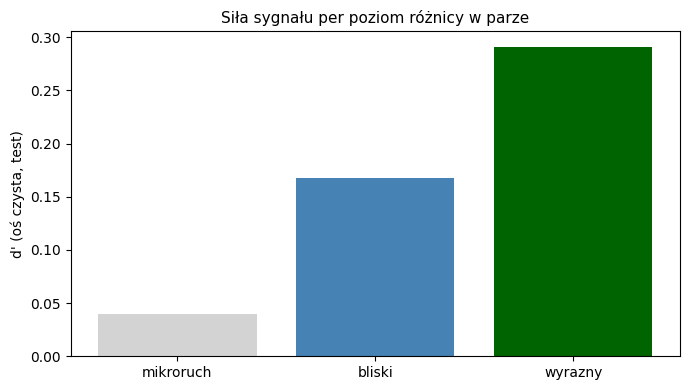

In [10]:
print('Sygnał per poziom similarity (oś czysta liczona na train całości):\n')
v_clean = clean['v']
results_lvl = {}
for lvl in ['wyrazny','bliski','mikroruch']:
    mask = (pairs['sim_level'] == lvl).values
    te_mask = np.zeros(len(pairs), bool); te_mask[te_idx] = True
    sel = mask & te_mask
    if sel.sum() < 30:
        print(f'  {lvl:10}: za mało par w teście ({sel.sum()})'); continue
    d_lvl = dprime_paired(E_c_clean[sel] @ v_clean, E_r_clean[sel] @ v_clean)
    results_lvl[lvl] = d_lvl
    print(f'  {lvl:10}: d\'={d_lvl:.3f}  (n={sel.sum()} par testowych)')

print('\nInterpretacja:')
print('  d\' rosnące od mikroruch→wyrazny = oś łapie MOMENT (różnicę realnych ujęć)')
print('  d\' płaskie/odwrotne = oś łapie coś innego (kolejny konfound? sprawdzić w Akcie 2)')

# Wykres
if len(results_lvl) == 3:
    fig, ax = plt.subplots(figsize=(7,4))
    lv = ['mikroruch','bliski','wyrazny']
    ax.bar(lv, [results_lvl[l] for l in lv], color=['lightgray','steelblue','darkgreen'])
    ax.set_ylabel("d' (oś czysta, test)")
    ax.set_title('Siła sygnału per poziom różnicy w parze', fontsize=11)
    plt.tight_layout(); plt.show()


## 9. Zapisz wyniki na Drive

In [11]:
out = {
    'raw_dprime': raw['dprime'], 'raw_acc': raw['acc'], 'raw_noise': raw['d_noise'],
    'clean_dprime': clean['dprime'], 'clean_acc': clean['acc'], 'clean_noise': clean['d_noise'],
    'per_level': results_lvl,
    'confounds': [d.name for d in ctrl.directions],
    'n_pairs': int(len(pairs)), 'n_train': int(len(tr_idx)), 'n_test': int(len(te_idx)),
}
with open(DRIVE / 'akt1_results.json', 'w') as f:
    json.dump(out, f, indent=2, default=float)
np.savez_compressed(DRIVE / 'akt1_axes.npz',
    v_raw=raw['v'], w_raw=raw['w'], v_clean=clean['v'], w_clean=clean['w'],
    v_hole=cd_hole.vector, v_sharp=cd_sharp.vector)
print('✅ Zapisano: akt1_results.json + akt1_axes.npz (osie do Aktu 2)')
print('\nNastępny krok: AKT 2 — interpretacja osi czystej przez sondy tekstowe CLIP')
print('(czasowe vs kompozycyjne vs ekspresyjne — nazwanie tego, co model odkrył)')


✅ Zapisano: akt1_results.json + akt1_axes.npz (osie do Aktu 2)

Następny krok: AKT 2 — interpretacja osi czystej przez sondy tekstowe CLIP
(czasowe vs kompozycyjne vs ekspresyjne — nazwanie tego, co model odkrył)
